## Health Insurance Claims
Health Insurance Underwriting with Simulated Health Insurance Dataset

### 1. Setup & Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Simulated Health Insurance Dataset

In [2]:
my_seed = 42
np.random.seed(my_seed)

# Generate 5000 datapoints
n = 5000
df = pd.DataFrame({
    "age": np.random.randint(18, 80, n),
    "bmi": np.random.normal(27, 5, n).round(1),
    "smoker": np.random.choice([0,1], n, p=[0.8, 0.2]),
    "chronic_conditions": np.random.poisson(0.6, n),
    "gender": np.random.choice(["M","F"], n),
    "region": np.random.choice(["North","South","East","West"], n),
})

# Claims cost model (synthetic)
df["claims_cost"] = (
    df["age"]*12 +
    df["bmi"]*15 +
    df["smoker"]*2000 +
    df["chronic_conditions"]*800 +
    np.random.normal(0, 500, n)
).clip(lower=0)

df.head()

,age,bmi,smoker,chronic_conditions,gender,region,claims_cost
0,56,11.9,0,0,M,East,802.010000
1,69,27.9,1,0,F,East,3223.745663
2,46,36.0,0,1,M,East,1520.168451
3,32,33.2,0,0,F,North,1022.834285
4,60,28.0,0,0,F,West,1348.900169


### Exploratory Data Analysis

In [3]:
# Set the plotting style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print("--- Data Snapshot ---")
print(df.head(), "\n")

--- Data Snapshot ---
   age   bmi  smoker  chronic_conditions gender region  claims_cost
0   56  11.9       0                   0      M   East   802.010000
1   69  27.9       1                   0      F   East  3223.745663
2   46  36.0       0                   1      M   East  1520.168451
3   32  33.2       0                   0      F  North  1022.834285
4   60  28.0       0                   0      F   West  1348.900169 



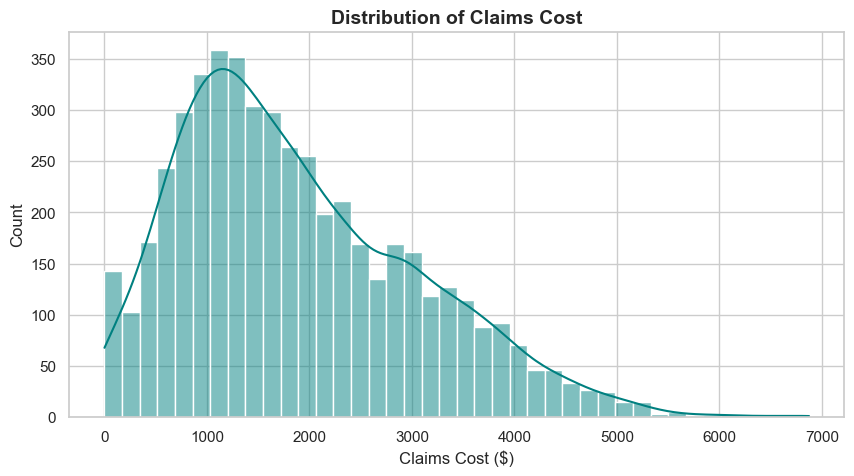

In [4]:
# Plot 1: Distribution of the Target Variable (claims_cost)
plt.figure(figsize=(10, 5))
sns.histplot(df['claims_cost'], kde=True, color='teal', bins=40)
plt.title('Distribution of Claims Cost', fontsize=14, fontweight='bold')
plt.xlabel('Claims Cost ($)')
plt.ylabel('Count')
plt.show()

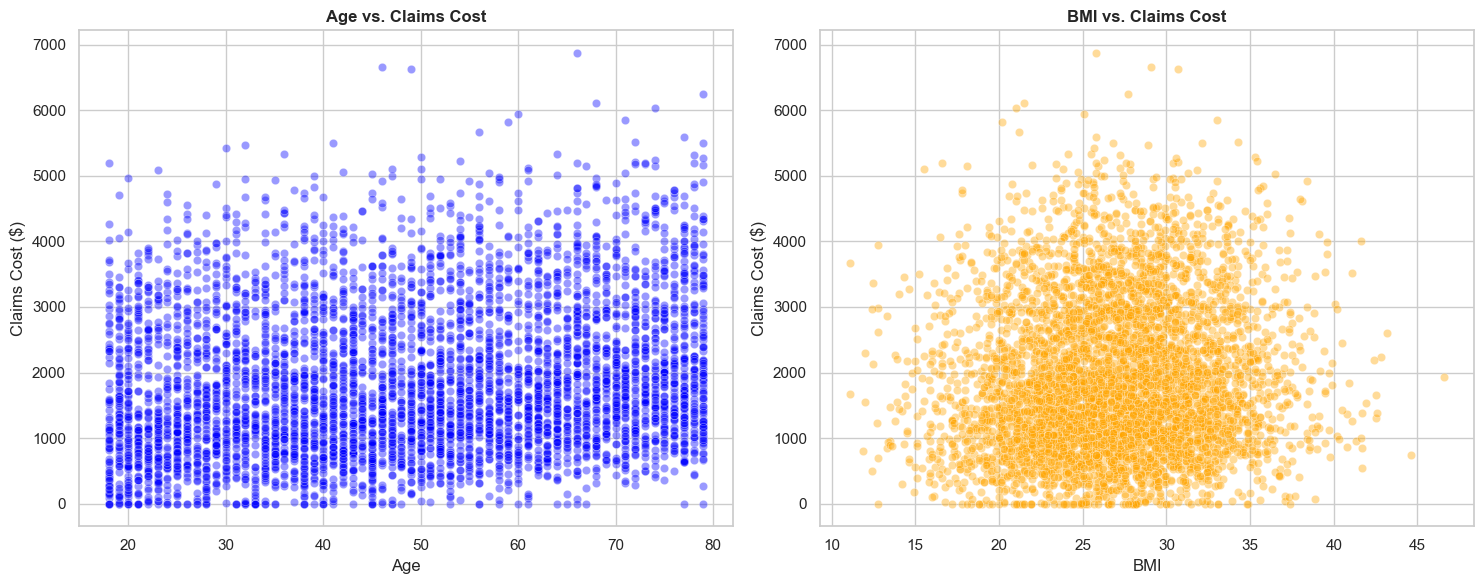

In [5]:
# Plot 2: Age & BMI vs. Claims Cost (Numerical Relationships)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='age', y='claims_cost', alpha=0.4, ax=axes[0], color='blue')
axes[0].set_title('Age vs. Claims Cost', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Claims Cost ($)')

sns.scatterplot(data=df, x='bmi', y='claims_cost', alpha=0.4, ax=axes[1], color='orange')
axes[1].set_title('BMI vs. Claims Cost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Claims Cost ($)')

plt.tight_layout()
plt.show()